In [1]:
# импорт необходимых библиотек
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor

In [2]:
#загрузка данных
wine = load_wine(as_frame=True)
data = wine.data
target = wine.target
data['target'] = target

In [3]:
#вывод датасета
data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
print(f"Размер датасета: {data.shape[0]} объектов, {data.shape[1]} признаков")

Размер датасета: 178 объектов, 14 признаков


In [5]:
#выведем статистические характеристики
data.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [6]:
#проверка на наличие пропусков
data.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

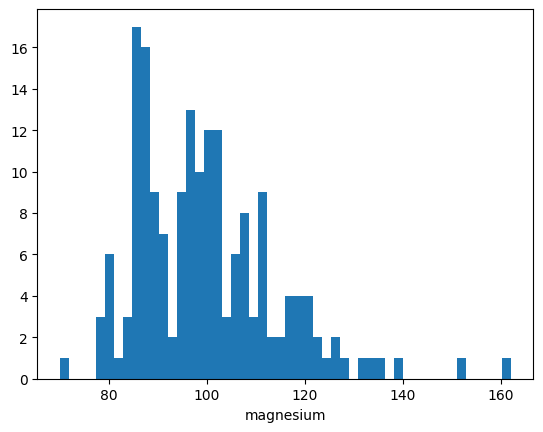

In [7]:
#визуализация распределения целевой переменной
y = data['magnesium']
plt.hist(y, 50)
plt.xlabel('magnesium')
plt.show()

<Axes: >

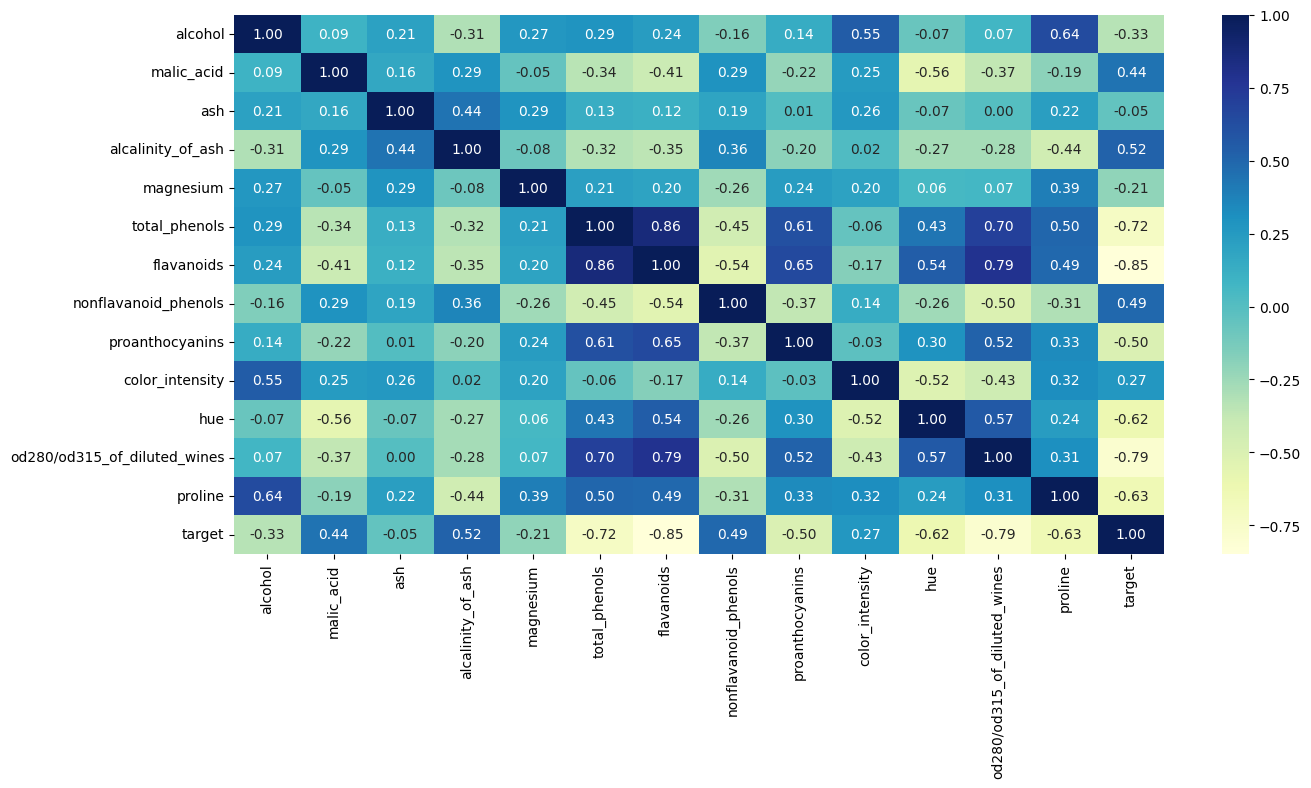

In [8]:
#Построим корреляционную матрицу
fig, ax = plt.subplots(figsize=(15,7))
sns.heatmap(data.corr(method='pearson'), cmap='YlGnBu', ax=ax, annot=True, fmt='.2f')

In [9]:
data = data.drop(columns=['magnesium']) 

In [10]:
#масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

In [11]:
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка: {X_test.shape[0]} объектов")

Обучающая выборка: 142 объектов
Тестовая выборка: 36 объектов


In [12]:
# стекинг 
print("Первый уровень: Линейная регрессия, Дерево решений, Случайный лес")
print("Второй уровень: Случайный лес")
results_mae = {}

# базовые модел 1 уровня
base_models = [
    ('dt', DecisionTreeRegressor(random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('lr', LinearRegression())
]

# стекинг-регрессор
stacking_reg = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression(),
    cv=5
)

stacking_reg.fit(X_train, y_train)

mae_stacking = mean_absolute_error(y_test, stacking_reg.predict(X_test))
results_mae['Stacking'] = mae_stacking

print(f"MAE: {mae_stacking}")

Первый уровень: Линейная регрессия, Дерево решений, Случайный лес
Второй уровень: Случайный лес
MAE: 8.738891989772993


In [13]:
# многослойный персептрон (MLP)
start_time = time.time()

mlp = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

mlp.fit(X_train, y_train)
train_time_mlp = time.time() - start_time

mae_mlp = mean_absolute_error(y_test, mlp.predict(X_test))
results_mae['MLP'] = mae_mlp

print(f"MAE: {mae_mlp}")

MAE: 39.95865747677624


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [14]:
# МГУА COMBI (линейный)
from gmdhpy import gmdh

combi_model = gmdh.MultilayerGMDH(ref_functions=gmdh.RefFunctionType.rfLinear)
combi_model.fit(X_train, y_train)

mae_combi = mean_absolute_error(y_test, combi_model.predict(X_test))
results_mae['COMBI (GMDH)'] = mae_combi

print(f"MAE: {mae_combi}")

train layer0 in 0.02 sec
train layer1 in 0.10 sec
train layer2 in 0.08 sec
train layer3 in 0.08 sec
train layer4 in 0.07 sec
train layer5 in 0.09 sec
train layer6 in 0.14 sec
train layer7 in 0.07 sec
train layer8 in 0.07 sec
MAE: 9.21534094688959


In [15]:
# МГУА MIA (нелинейный)
mia_model = gmdh.MultilayerGMDH(
    ref_functions=(gmdh.RefFunctionType.rfLinearCov, 
                   gmdh.RefFunctionType.rfQuadratic, 
                   gmdh.RefFunctionType.rfCubic)
)
mia_model.fit(X_train, y_train)

mae_mia = mean_absolute_error(y_test, mia_model.predict(X_test))
results_mae['MIA (GMDH)'] = mae_mia

print(f"MAE: {mae_mia}")

train layer0 in 0.06 sec
train layer1 in 0.23 sec
train layer2 in 0.22 sec
train layer3 in 0.22 sec
train layer4 in 0.22 sec
train layer5 in 0.22 sec
train layer6 in 0.22 sec
train layer7 in 0.23 sec
train layer8 in 0.22 sec
MAE: 8.735394401291247


In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from matplotlib.patches import Patch

#расчет метрик
results_full = {}

models_dict = {
    'Stacking': stacking_reg,
    'MLP': mlp,
    'COMBI (GMDH)': combi_model,
    'MIA (GMDH)': mia_model
}

for name, model in models_dict.items():
    y_pred = model.predict(X_test)
    results_full[name] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAPE': np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    }

print("\nРезультаты оценки качества на тестовой выборке:")

print(f"{'Модель':<25}{'MAE':<12}{'RMSE':<12}{'MAPE':<12}")
for name in models_dict.keys():
    metr = results_full[name]
    print(f"{name:<25}{metr['MAE']:<12.5f}{metr['RMSE']:<12.5f}{metr['MAPE']:<12.5f}")


Результаты оценки качества на тестовой выборке:
Модель                   MAE         RMSE        MAPE        
Stacking                 8.73889     10.96596    9.39504     
MLP                      39.95866    43.15920    41.23282    
COMBI (GMDH)             9.21534     10.57962    10.08868    
MIA (GMDH)               8.73539     10.10457    9.40547     


In [17]:
best_mape = min(results_full, key=lambda x: results_full[x]['MAPE'])
print(f"\nЛучшая модель:  {best_mape}")


Лучшая модель:  Stacking
